## Project Ironhack Payments

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_cash_requests= pd.read_csv(r"/Users/turfdiddy/Desktop/Bootcamp_ds:ml/Week 2/Day_3/project-1-ironhack-payments-2-en/project_dataset/extract - cash request - data analyst.csv")
df_fees= pd.read_csv(r"/Users/turfdiddy/Desktop/Bootcamp_ds:ml/Week 2/Day_3/project-1-ironhack-payments-2-en/project_dataset/extract - fees - data analyst - .csv")

In [4]:
df_cash_requests.head()

,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update
0,5,100.0,rejected,2019-12-10 19:05:21.596873+00,2019-12-11 16:47:42.40783+00,804.0,2019-12-11 16:47:42.405646+00,NaN,2020-01-09 19:05:21.596363+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
1,70,100.0,rejected,2019-12-10 19:50:12.34778+00,2019-12-11 14:24:22.900054+00,231.0,2019-12-11 14:24:22.897988+00,NaN,2020-01-09 19:50:12.34778+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
2,7,100.0,rejected,2019-12-10 19:13:35.82546+00,2019-12-11 09:46:59.779773+00,191.0,2019-12-11 09:46:59.777728+00,NaN,2020-01-09 19:13:35.825041+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
3,10,99.0,rejected,2019-12-10 19:16:10.880172+00,2019-12-18 14:26:18.136163+00,761.0,2019-12-18 14:26:18.128407+00,NaN,2020-01-09 19:16:10.879606+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
4,1594,100.0,rejected,2020-05-06 09:59:38.877376+00,2020-05-07 09:21:55.34008+00,7686.0,2020-05-07 09:21:55.320193+00,NaN,2020-06-05 22:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN


In [5]:
df_fees.head()

,id,cash_request_id,type,status,category,total_amount,reason,created_at,updated_at,paid_at,from_date,to_date,charge_moment
0,6537,14941.0,instant_payment,rejected,NaN,5.0,Instant Payment Cash Request 14941,2020-09-07 10:47:27.42315+00,2020-10-13 14:25:09.396112+00,2020-12-17 14:50:07.47011+00,NaN,NaN,after
1,6961,11714.0,incident,accepted,rejected_direct_debit,5.0,rejected direct debit,2020-09-09 20:51:17.998653+00,2020-10-13 14:25:15.537063+00,2020-12-08 17:13:10.45908+00,NaN,NaN,after
2,16296,23371.0,instant_payment,accepted,NaN,5.0,Instant Payment Cash Request 23371,2020-10-23 10:10:58.352972+00,2020-10-23 10:10:58.352994+00,2020-11-04 19:34:37.43291+00,NaN,NaN,after
3,20775,26772.0,instant_payment,accepted,NaN,5.0,Instant Payment Cash Request 26772,2020-10-31 15:46:53.643958+00,2020-10-31 15:46:53.643982+00,2020-11-19 05:09:22.500223+00,NaN,NaN,after
4,11242,19350.0,instant_payment,accepted,NaN,5.0,Instant Payment Cash Request 19350,2020-10-06 08:20:17.170432+00,2020-10-13 14:25:03.267983+00,2020-11-02 14:45:20.355598+00,NaN,NaN,after


# Data Quality Analysis + EDA

In [7]:
df_fees.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21061 entries, 0 to 21060
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               21061 non-null  int64  
 1   cash_request_id  21057 non-null  float64
 2   type             21061 non-null  object 
 3   status           21061 non-null  object 
 4   category         2196 non-null   object 
 5   total_amount     21061 non-null  float64
 6   reason           21061 non-null  object 
 7   created_at       21061 non-null  object 
 8   updated_at       21061 non-null  object 
 9   paid_at          15531 non-null  object 
 10  from_date        7766 non-null   object 
 11  to_date          7766 non-null   object 
 12  charge_moment    21061 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [8]:
df_cash_requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          23970 non-null  int64  
 1   amount                      23970 non-null  float64
 2   status                      23970 non-null  object 
 3   created_at                  23970 non-null  object 
 4   updated_at                  23970 non-null  object 
 5   user_id                     21867 non-null  float64
 6   moderated_at                16035 non-null  object 
 7   deleted_account_id          2104 non-null   float64
 8   reimbursement_date          23970 non-null  object 
 9   cash_request_received_date  16289 non-null  object 
 10  money_back_date             16543 non-null  object 
 11  transfer_type               23970 non-null  object 
 12  send_at                     16641 non-null  object 
 13  recovery_status             333

In [ ]:
df_cash_requests.isnull() # checks to see if there are columns with NaN and NaT values and returns a boolean True if they exist

,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update
0,False,False,False,False,False,False,False,True,False,True,True,False,True,True,True,True
1,False,False,False,False,False,False,False,True,False,True,True,False,True,True,True,True
2,False,False,False,False,False,False,False,True,False,True,True,False,True,True,True,True
3,False,False,False,False,False,False,False,True,False,True,True,False,True,True,True,True
4,False,False,False,False,False,False,False,True,False,True,True,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,False,False,False,False,False,False,True,True,False,False,False,False,False,True,True,True
23966,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False
23967,False,False,False,False,False,False,True,True,False,False,False,False,False,True,True,True
23968,False,False,False,False,False,False,True,True,False,False,False,False,False,True,True,True


In [10]:
df_fees.isnull()

,id,cash_request_id,type,status,category,total_amount,reason,created_at,updated_at,paid_at,from_date,to_date,charge_moment
0,False,False,False,False,True,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,True,False,False,False,False,False,True,True,False
3,False,False,False,False,True,False,False,False,False,False,True,True,False
4,False,False,False,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21056,False,False,False,False,True,False,False,False,False,False,True,True,False
21057,False,False,False,False,True,False,False,False,False,False,True,True,False
21058,False,False,False,False,True,False,False,False,False,False,True,True,False
21059,False,False,False,False,True,False,False,False,False,False,True,True,False


In [11]:
df_cash_requests.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
23965    False
23966    False
23967    False
23968    False
23969    False
Length: 23970, dtype: bool

In [12]:
df_fees.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
21056    False
21057    False
21058    False
21059    False
21060    False
Length: 21061, dtype: bool

In [13]:
df_cash_requests.value_counts()

Series([], Name: count, dtype: int64)

In [14]:
'''df['column_name'].value_counts() 
example 
df['product_category'] = ['Books', 'Books', 'Games', 'Games', 'Games', 'Electronics']

and i run the code df['product_category'].value_counts(), it returns an output counting how many times games appeared in the column product_category within this dataframe. so in this case Games = 3 times books 2 times , electronics 1 time. 

 📌 Use Cases of value count; 
	•	Finding the most common value in a column
	•	Checking distribution of categories (for bar plots, pie charts, etc.)
	•	Quick exploratory data analysis (EDA) step

    df['product_category'].value_counts()
    shows how many times each mentioned column appears within the dataframe

    df['product_category'].value_counts(normalize=True)
    normalize = True shows the proportion of each category. 

    df['product_category'].value_counts(dropna=False)
    🔍 What you learn:
	•	How many missing or NaN entries exist
	•	If you have “Unknown”, “Other”, or blank values that need cleaning

    Great follow-up! The dropna parameter in .value_counts() controls whether missing values (NaN) are counted or excluded from the output.


df['column'].value_counts(dropna=False) 
dropna= False includes NaN values in the column
 without dropna, NaN values are ignored and only columns with values are returned

 dropna only good if :	
                    	Looking for missing or incomplete entries
	                    Preparing to fill or drop NaNs'''

"df['column_name'].value_counts() \nexample \ndf['product_category'] = ['Books', 'Books', 'Games', 'Games', 'Games', 'Electronics']\n\nand i run the code df['product_category'].value_counts(), it returns an output counting how many times games appeared in the column product_category within this dataframe. so in this case Games = 3 times books 2 times , electronics 1 time. \n\n 📌 Use Cases of value count; \n\t•\tFinding the most common value in a column\n\t•\tChecking distribution of categories (for bar plots, pie charts, etc.)\n\t•\tQuick exploratory data analysis (EDA) step\n\n    df['product_category'].value_counts()\n    shows how many times each mentioned column appears within the dataframe\n\n    df['product_category'].value_counts(normalize=True)\n    normalize = True shows the proportion of each category. \n\n    df['product_category'].value_counts(dropna=False)\n    🔍 What you learn:\n\t•\tHow many missing or NaN entries exist\n\t•\tIf you have “Unknown”, “Other”, or blank valu

In [15]:
'''🔍 What .unique() Does

df['column_name'].unique()

The .unique() method returns a NumPy array of all the distinct (unique) values in a Pandas Series (usually a column of a DataFrame).

⸻

📦 What You Get:
	•	All non-repeating values in the order they first appear
	•	Includes NaN if it exists
	•	No counts — just the raw unique values

🧠 Why You Use It:
	•	To quickly inspect what values exist in a categorical column
	•	To check for inconsistencies or data entry errors (e.g. "Male", "male", "MALE")
	•	To explore possible class labels in a classification task
	•	To prepare for encoding or filtering.  '''


'🔍 What .unique() Does\n\ndf[\'column_name\'].unique()\n\nThe .unique() method returns a NumPy array of all the distinct (unique) values in a Pandas Series (usually a column of a DataFrame).\n\n⸻\n\n📦 What You Get:\n\t•\tAll non-repeating values in the order they first appear\n\t•\tIncludes NaN if it exists\n\t•\tNo counts — just the raw unique values\n\n🧠 Why You Use It:\n\t•\tTo quickly inspect what values exist in a categorical column\n\t•\tTo check for inconsistencies or data entry errors (e.g. "Male", "male", "MALE")\n\t•\tTo explore possible class labels in a classification task\n\t•\tTo prepare for encoding or filtering.  '

In [ ]:
'''Subsetting a DataFrame in Pandas

There are several ways to subset a DataFrame depending on what you want to filter: **columns**, **rows**, or **both**.

1. ✅ Subset by Columns (Column Selection)

```python
df_subset = df[['col1', 'col2', 'col3']]

Selects only the specified columns from the original DataFrame.

📌 Useful for:
	•	Reducing the dataset to relevant features
	•	Preparing a clean version of your dataset for analysis or modeling

    
✅ 2. Subset by Rows (Boolean Filtering)
df_filtered = df[df['status'] == 'sent']

example
beauty_products = df[df['category'] == 'Beauty'] #subset of beauty_products from the main dataframe that dsiplays all the products within the beauty category


Selects only rows that meet a specific condition.

📌 Useful for:
	•	Filtering data based on values
	•	Isolating a group of interest (e.g., sent vs. pending)

✅ 3. Subset by Both Rows and Columns
df_subset = df.loc[df['status'] == 'sent', ['id', 'send_at']]


📌 Useful for:
	•	Creating a tightly focused dataset for a specific analysis or chart
	•	Combining row and column logic in one line

'''

"Subsetting a DataFrame in Pandas\n\nThere are several ways to subset a DataFrame depending on what you want to filter: **columns**, **rows**, or **both**.\n\n1. ✅ Subset by Columns (Column Selection)\n\n```python\ndf_subset = df[['col1', 'col2', 'col3']]\n\nSelects only the specified columns from the original DataFrame.\n\n📌 Useful for:\n\t•\tReducing the dataset to relevant features\n\t•\tPreparing a clean version of your dataset for analysis or modeling\n\n    \n✅ 2. Subset by Rows (Boolean Filtering)\ndf_filtered = df[df['status'] == 'sent']\n\nSelects only rows that meet a specific condition.\n\n📌 Useful for:\n\t•\tFiltering data based on values\n\t•\tIsolating a group of interest (e.g., sent vs. pending)\n\n✅ 3. Subset by Both Rows and Columns\ndf_subset = df.loc[df['status'] == 'sent', ['id', 'send_at']]\n\n\n📌 Useful for:\n\t•\tCreating a tightly focused dataset for a specific analysis or chart\n\t•\tCombining row and column logic in one line\n\n"

In [18]:
cash_request_clean=df_cash_requests[['id','created_at','updated_at','send_at','status']]

In [20]:
fees_clean=df_fees[['id','type','category','status','total_amount']]

In [21]:
print(cash_request_clean.dtypes)

id             int64
created_at    object
updated_at    object
send_at       object
status        object
dtype: object


In [22]:
print(fees_clean.dtypes)

id                int64
type             object
category         object
status           object
total_amount    float64
dtype: object


In [ ]:
#we want to convert the dates in the cash request columns to date time. These columns are created_at , send_at, updated_at. To do this we use the pd.to_datetime(df.date).reset_index()

In [23]:
''' the copy function is needed here before creating the date to datetime conversion 
because 

✅ 1. It creates a true, independent copy of your selected DataFrame columns

✅ 2. It gives you a safe workspace to convert date strings to datetime objects

Using .copy() is a good practice when:
	•	You’re transforming or cleaning a subset of data
	•	You want to prevent accidental changes to the original
	•	You want clean, readable, and stable code


'''

' the copy function is needed here before creating the date to datetime conversion \nbecause \n\n✅ 1. It creates a true, independent copy of your selected DataFrame columns\n\n✅ 2. It gives you a safe workspace to convert date strings to datetime objects\n\nUsing .copy() is a good practice when:\n\t•\tYou’re transforming or cleaning a subset of data\n\t•\tYou want to prevent accidental changes to the original\n\t•\tYou want clean, readable, and stable code\n\n\n'

In [24]:
# Safely create a new DataFrame with only the needed columns
cash_request_clean = df_cash_requests[['id', 'created_at', 'updated_at', 'send_at', 'status']].copy()

# Convert date-related columns to datetime format
columns_to_convert = ['created_at', 'updated_at', 'send_at']

for column in columns_to_convert:
    cash_request_clean[column] = pd.to_datetime(cash_request_clean[column], errors='coerce')

# Check the updated data types
print(cash_request_clean.dtypes)

id                          int64
created_at    datetime64[ns, UTC]
updated_at    datetime64[ns, UTC]
send_at       datetime64[ns, UTC]
status                     object
dtype: object


### univariate analysis 

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/3321810739.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


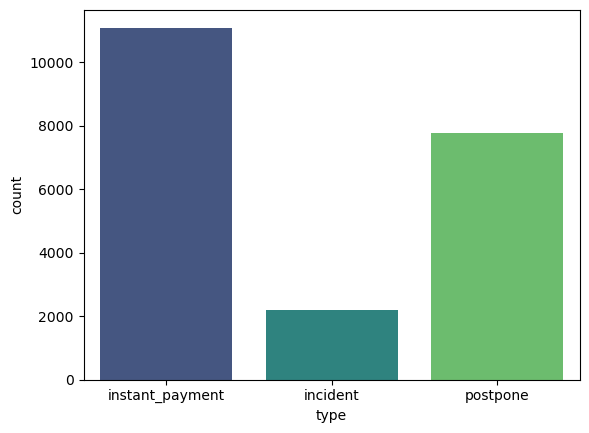

In [ ]:
type_counts=fees_clean['type'].value_counts().reset_index()

'''This creates a dataframe by using reset_index for type which is a column with the fees dataframe. 

Using the various visualisation methods require a dataframe to work from in order for the frequency to be read

This is however only necessary for barplot where we are working with filtered/aggregated data

countplot allows us to read raw data meaning no need to create another dataframe'''

'''Visualizing Categorical Variables: `value_counts()`, `countplot()`, and `barplot()`

When analyzing a categorical column like `'type'` (e.g., fee types or transaction types), here are two main ways to visualize the distribution:

---

### ✅ 1. Using `sns.countplot()` (Recommended for Raw Data)

- Automatically counts the occurrences of each category.
- Use the **original DataFrame** (`fees_clean`) — no need to pre-aggregate.

✅ 2. Using sns.barplot() with Aggregated Data
	•	Use if you’ve already counted values with .value_counts() and want full control.

'''



sns.countplot(
    x="type",
    data=fees_clean,

    palette='viridis',
    legend=False,
)
plt.show()

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/565038491.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


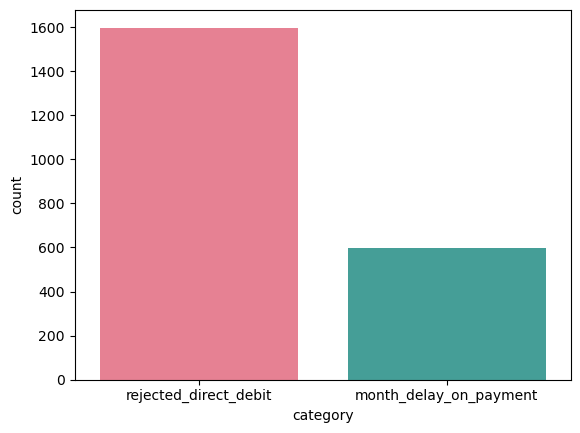

In [32]:
sns.countplot(
    x='category',
    data=fees_clean,
    palette='husl',
    legend= False , 
)
plt.show()

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/1702267852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


'example using barplot'

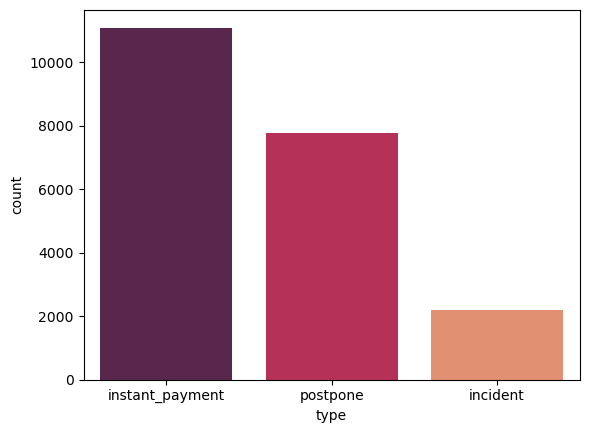

In [30]:
# Plot with barplot
sns.barplot(
    x='type',
    y='count',
    data=type_counts,
    palette='rocket'
)

'''example using barplot'''

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/2557694870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


'example using barplot'

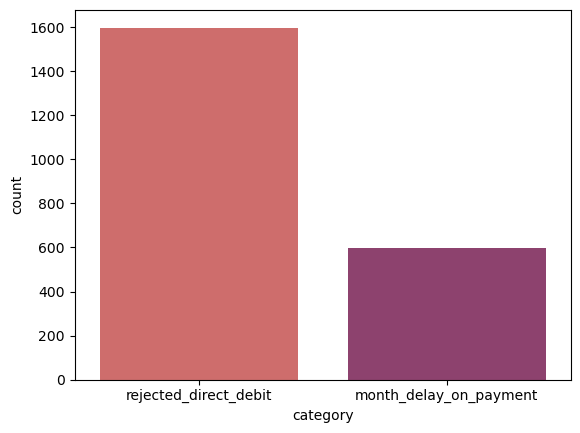

In [37]:
type_counts = fees_clean["category"].value_counts().reset_index()


# Plot with barplot
sns.barplot(
    x='category',
    y='count',
    data=type_counts,
    palette='flare',
    legend=True
)

'''example using barplot'''

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/301391978.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


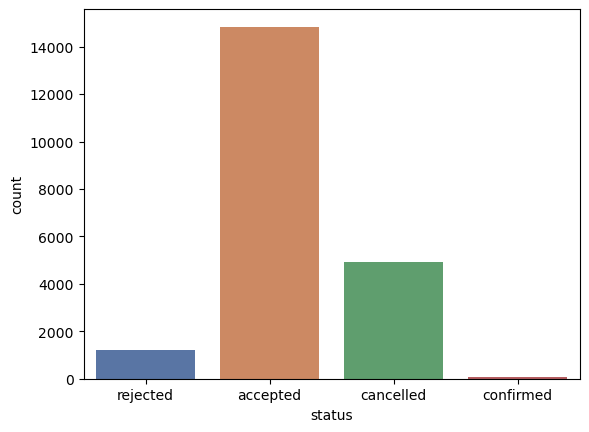

In [39]:
sns.countplot(
    x='status',
    data=fees_clean,
    palette='deep',
    legend= False , 
)
plt.show()

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/3674695484.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='status', ylabel='count'>

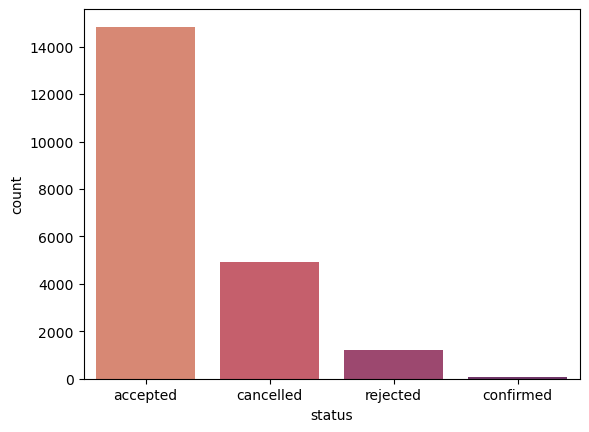

In [40]:
type_counts = fees_clean["status"].value_counts().reset_index()
type_counts.head()
sns.barplot(
    x='status',
    y='count',
    data=type_counts,
    palette='flare',
    legend=True
)


In [41]:
type_counts.head()

,status,count
0,accepted,14841
1,cancelled,4938
2,rejected,1194
3,confirmed,88


## Creating Cohorts

In [42]:
# Group the cash requests by 'id' and find the earliest 'send_at' date for each id
user_first_send = cash_request_clean.groupby('id')['send_at'].min().reset_index()

# Rename columns
user_first_send.columns = ['user_id', 'first_send_date']

# Format 'first_send_date' as "Month Year" and store as a cohort
user_first_send['cohort'] = user_first_send['first_send_date'].dt.strftime('%B %Y')

# Count how many users fall into each cohort
cohort_distribution = user_first_send['cohort'].value_counts().sort_index()

# Print the results
print(cohort_distribution)

# Save to CSV
user_first_send.to_csv('cohort.csv', index=False)

cohort
August 2020       3671
July 2020          469
November 2020      290
October 2020      8974
September 2020    3062
Name: count, dtype: int64


## merging with fees

In [43]:
fees_with_users = fees_clean.merge(cash_request_clean, on='id', how='left')

In [44]:
## adding /merging the cohort to the fees with users dataframe

fees_with_users = fees_with_users.merge(
    user_first_send[['user_id', 'cohort']],
    left_on='id',
    right_on='user_id',
    how='left'
)
fees_with_users

,id,type,category,status_x,total_amount,created_at,updated_at,send_at,status_y,user_id,cohort
0,6537,instant_payment,NaN,rejected,5.0,2020-07-04 05:59:49.246265+00:00,2020-12-18 13:09:59.300546+00:00,NaT,money_back,6537.0,NaN
1,6961,incident,rejected_direct_debit,accepted,5.0,2020-07-07 17:45:03.352406+00:00,2020-12-18 13:10:14.466442+00:00,NaT,money_back,6961.0,NaN
2,16296,instant_payment,NaN,accepted,5.0,2020-09-15 19:05:39.267562+00:00,2020-12-18 13:09:14.593043+00:00,2020-09-22 19:05:39.221698+00:00,money_back,16296.0,September 2020
3,20775,instant_payment,NaN,accepted,5.0,2020-10-13 08:15:07.746660+00:00,2020-12-18 13:11:57.614945+00:00,2020-10-13 08:16:15.684807+00:00,money_back,20775.0,October 2020
4,11242,instant_payment,NaN,accepted,5.0,2020-08-06 22:46:50.681779+00:00,2020-12-18 13:10:59.725981+00:00,2020-08-13 22:46:50.681310+00:00,money_back,11242.0,August 2020
...,...,...,...,...,...,...,...,...,...,...,...
21056,12372,instant_payment,NaN,rejected,5.0,2020-08-13 15:21:44.956497+00:00,2020-08-14 07:08:21.821427+00:00,2020-08-20 15:21:44.920490+00:00,rejected,12372.0,August 2020
21057,20768,instant_payment,NaN,rejected,5.0,2020-10-13 07:46:38.698727+00:00,2020-12-18 13:08:54.925808+00:00,2020-10-13 07:46:50.172820+00:00,money_back,20768.0,October 2020
21058,18779,instant_payment,NaN,rejected,5.0,2020-10-01 18:51:01.003129+00:00,2020-10-02 07:41:55.392915+00:00,2020-10-08 18:51:00.974920+00:00,rejected,18779.0,October 2020
21059,16542,instant_payment,NaN,rejected,5.0,2020-09-17 07:33:06.068449+00:00,2020-12-18 13:10:48.112461+00:00,2020-09-24 07:33:06.014806+00:00,money_back,16542.0,September 2020


In [45]:
incident_count=fees_with_users.groupby(['cohort', 'type']).size().unstack(fill_value=0)

In [46]:
cohort_total= incident_count.sum(axis=1)

In [47]:
incident_rate=incident_count.divide(cohort_total , axis=0)

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/3287794645.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  incident_rate.index = pd.to_datetime(incident_rate.index)


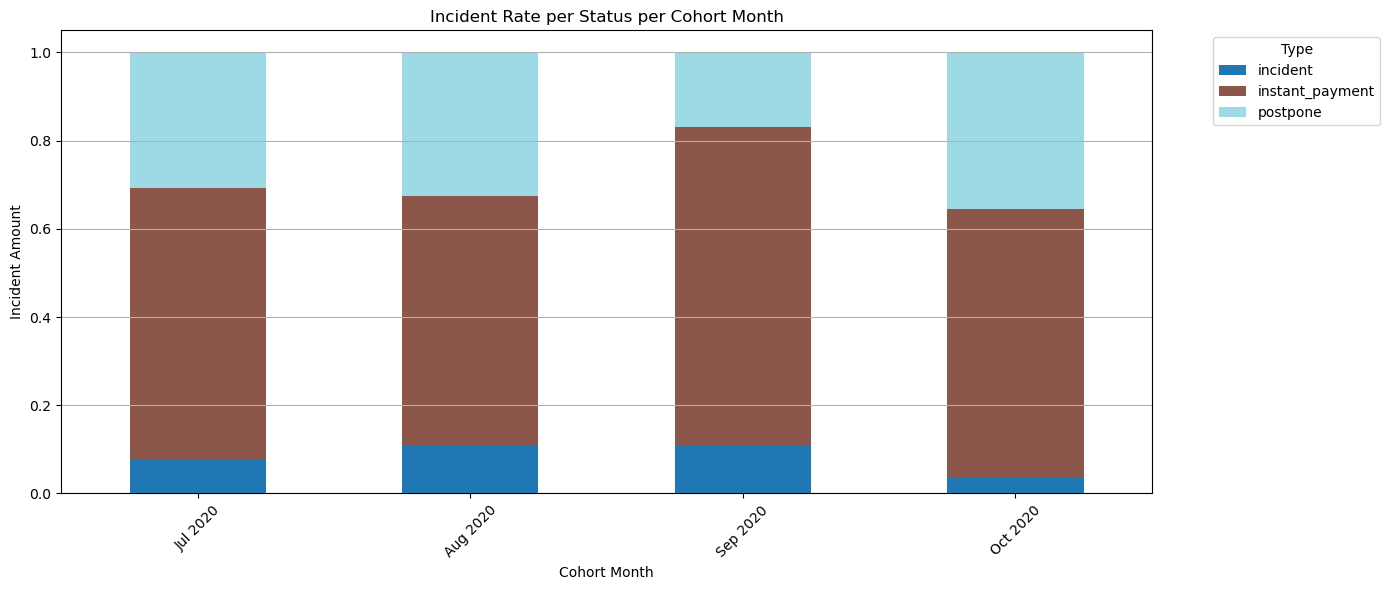

In [53]:
# ✅ Ensure index is datetime and sorted in chronological order
incident_rate.index = pd.to_datetime(incident_rate.index)
incident_rate = incident_rate.sort_index()

# ✅ Optional: Convert index to readable month-year labels for the x-axis
incident_rate.index = incident_rate.index.strftime('%b %Y')

# ✅ Create stacked bar plot
incident_rate.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='tab20',
    title='Incident Rate per Status per Cohort Month'
)

# ✅ Formatting
plt.xlabel('Cohort Month')
plt.ylabel('Incident Amount')
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [55]:
incident_rate.head()

type,incident,instant_payment,postpone
cohort,,,
Jul 2020,0.076759,0.616205,0.307036
Aug 2020,0.106685,0.566712,0.326603
Sep 2020,0.108859,0.722785,0.168356
Oct 2020,0.037056,0.607411,0.355533


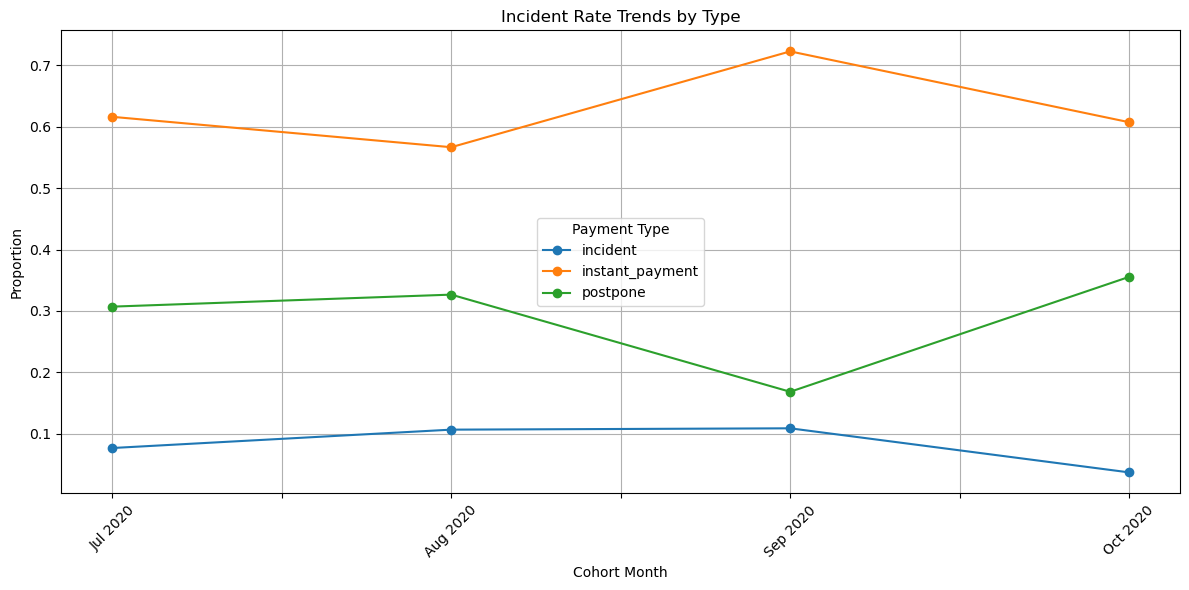

In [59]:
incident_rate.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Incident Rate Trends by Type'
)

plt.xlabel('Cohort Month')
plt.ylabel('Proportion')
plt.legend(title='Payment Type')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
fees_with_users.groupby("send_at").agg("count")

,id,type,category,status_x,total_amount,created_at,updated_at,status_y,user_id,cohort
send_at,,,,,,,,,,
2020-07-27 13:02:24.293568+00:00,1,1,0,1,1,1,1,1,1,1
2020-07-27 13:06:49.529731+00:00,1,1,0,1,1,1,1,1,1,1
2020-07-27 13:22:16.338042+00:00,1,1,0,1,1,1,1,1,1,1
2020-07-27 13:25:54.391448+00:00,1,1,0,1,1,1,1,1,1,1
2020-07-27 13:26:07.623454+00:00,1,1,0,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
2020-10-21 16:39:37.410688+00:00,1,1,0,1,1,1,1,1,1,1
2020-10-21 21:33:00.484995+00:00,1,1,0,1,1,1,1,1,1,1
2020-10-21 22:13:38.328337+00:00,1,1,0,1,1,1,1,1,1,1


In [66]:
# Convert created_at to datetime if not already
fees_with_users['created_at'] = pd.to_datetime(fees_with_users['created_at'], errors='coerce')

# Create usage_month
fees_with_users['usage_month'] = fees_with_users['created_at'].dt.to_period('M')

# Group by cohort and usage month
usage_counts = fees_with_users.groupby(['cohort', 'usage_month']).size().reset_index(name='usage_count')

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/1012308251.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  fees_with_users['usage_month'] = fees_with_users['created_at'].dt.to_period('M')


In [67]:
# Ensure 'send_at' is in datetime format
cash_request_clean['send_at'] = pd.to_datetime(cash_request_clean['send_at'], errors='coerce')

# Drop missing 'send_at'
cash_request_clean = cash_request_clean.dropna(subset=['send_at'])

# Extract full month name (e.g., 'July', 'August')
cash_request_clean['usage_month'] = cash_request_clean['send_at'].dt.strftime('%B')

# Define a categorical month order (optional: for correct sorting)
month_order = ['July', 'August', 'September', 'October', 'November',]
cash_request_clean['usage_month'] = pd.Categorical(cash_request_clean['usage_month'], categories=month_order, ordered=True)

# Count occurrences
monthly_usage = cash_request_clean['usage_month'].value_counts().sort_index()

In [69]:
print(usage_counts.dtypes)

cohort            object
usage_month    period[M]
usage_count        int64
dtype: object


In [70]:
usage_counts['usage_month'] = usage_counts['usage_month'].astype(str)

In [71]:
usage_counts['usage_count'] = pd.to_numeric(usage_counts['usage_count'], errors='coerce')

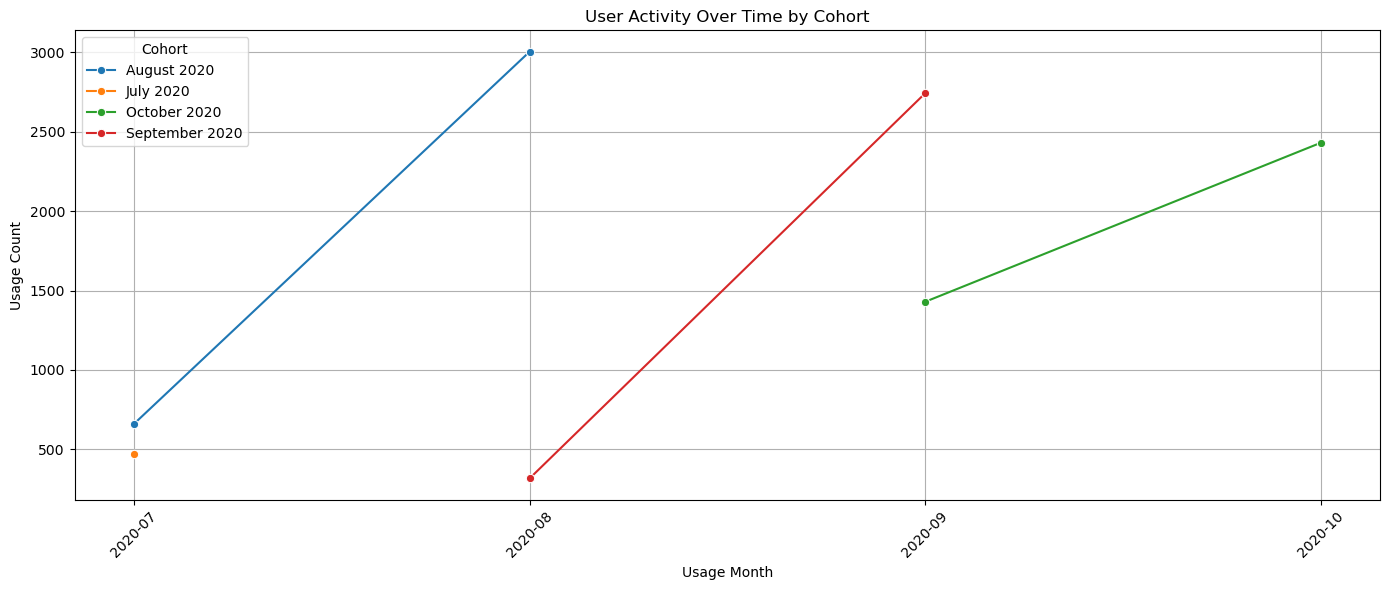

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=usage_counts,
    x='usage_month',
    y='usage_count',
    hue='cohort',
    marker='o'
)

plt.title('User Activity Over Time by Cohort')
plt.xlabel('Usage Month')
plt.ylabel('Usage Count')
plt.xticks(rotation=45)
plt.legend(title='Cohort')
plt.tight_layout()
plt.grid(True)
plt.show()

In [73]:
heatmap_data = usage_counts.pivot(index='cohort', columns='usage_month', values='usage_count')

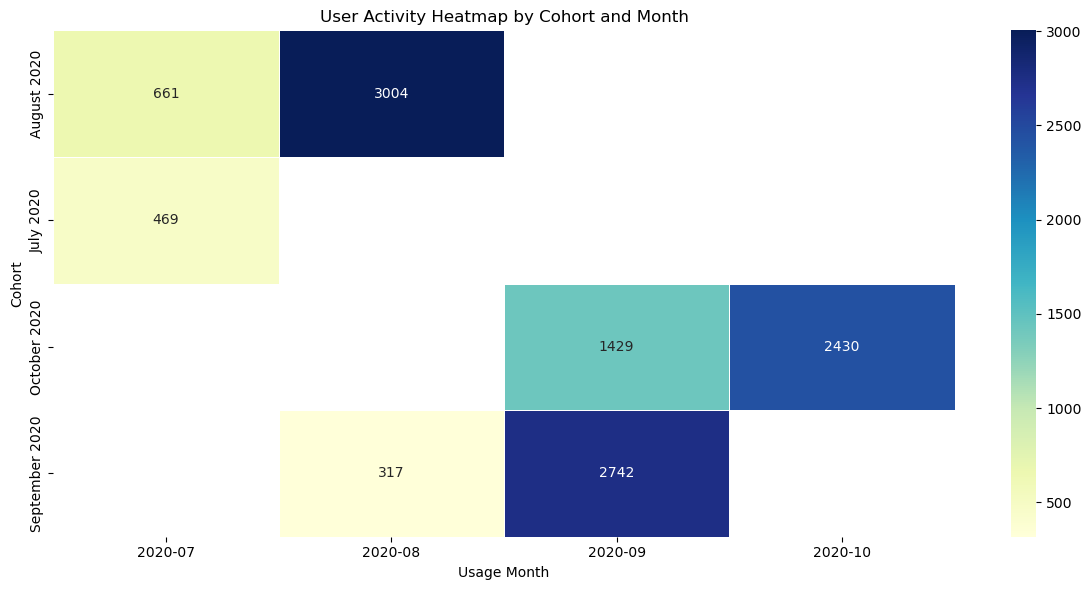

In [74]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title('User Activity Heatmap by Cohort and Month')
plt.xlabel('Usage Month')
plt.ylabel('Cohort')
plt.tight_layout()
plt.show()

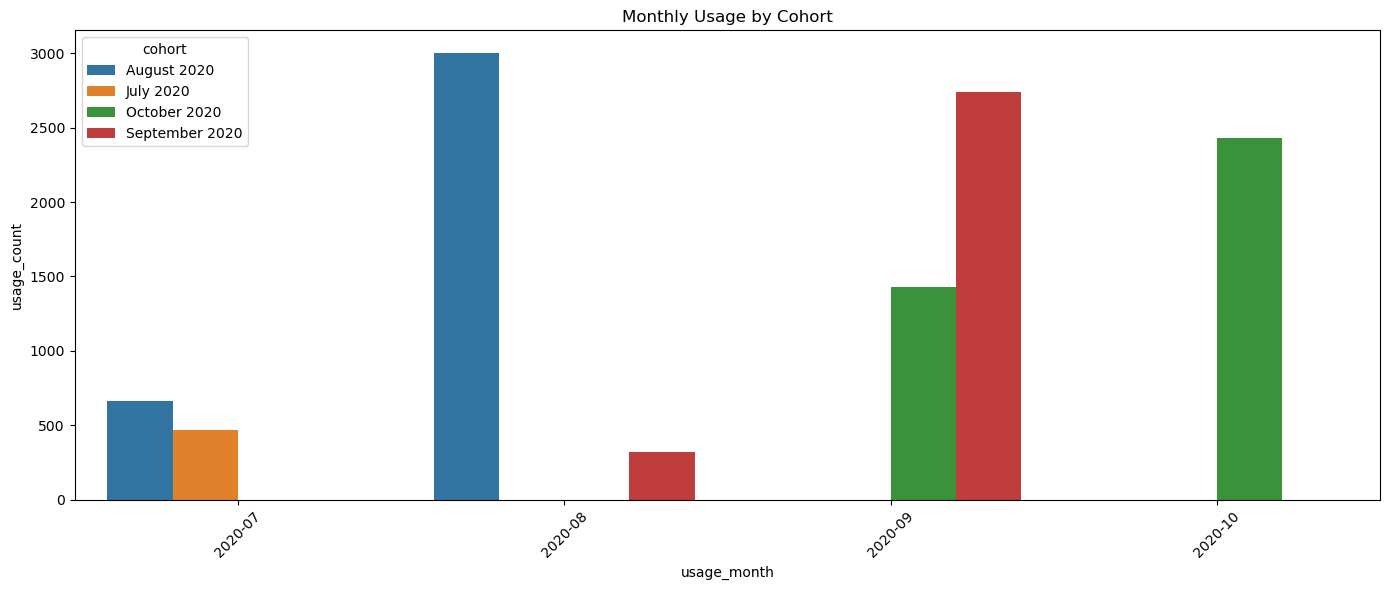

In [75]:
plt.figure(figsize=(14, 6))
sns.barplot(data=usage_counts, x='usage_month', y='usage_count', hue='cohort')
plt.title('Monthly Usage by Cohort')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
fees_with_users['cohort'].value_counts().sort_index()

cohort
August 2020       3665
July 2020          469
October 2020      3859
September 2020    3059
Name: count, dtype: int64

## total revenue

In [77]:
subset_merged_df = fees_with_users[fees_with_users['status_x'] == 'accepted']

In [82]:
subset_merged_df

,id,type,category,status_x,total_amount,created_at,updated_at,send_at,status_y,user_id,cohort,usage_month
1,6961,incident,rejected_direct_debit,accepted,5.0,2020-07-07 17:45:03.352406+00:00,2020-12-18 13:10:14.466442+00:00,NaT,money_back,6961.0,NaN,2020-07
2,16296,instant_payment,NaN,accepted,5.0,2020-09-15 19:05:39.267562+00:00,2020-12-18 13:09:14.593043+00:00,2020-09-22 19:05:39.221698+00:00,money_back,16296.0,September 2020,2020-09
3,20775,instant_payment,NaN,accepted,5.0,2020-10-13 08:15:07.746660+00:00,2020-12-18 13:11:57.614945+00:00,2020-10-13 08:16:15.684807+00:00,money_back,20775.0,October 2020,2020-10
4,11242,instant_payment,NaN,accepted,5.0,2020-08-06 22:46:50.681779+00:00,2020-12-18 13:10:59.725981+00:00,2020-08-13 22:46:50.681310+00:00,money_back,11242.0,August 2020,2020-08
5,17029,instant_payment,NaN,accepted,5.0,2020-09-21 06:17:14.044173+00:00,2020-12-18 13:11:03.097376+00:00,2020-09-28 06:17:13.995704+00:00,money_back,17029.0,September 2020,2020-09
...,...,...,...,...,...,...,...,...,...,...,...,...
20997,12867,instant_payment,NaN,accepted,5.0,2020-08-18 05:07:56.130552+00:00,2020-08-18 09:21:01.619758+00:00,2020-08-25 05:07:56.082082+00:00,rejected,12867.0,August 2020,2020-08
21002,15712,incident,rejected_direct_debit,accepted,5.0,2020-09-11 13:23:48.422634+00:00,2020-12-18 13:10:49.840215+00:00,2020-09-18 13:23:48.380809+00:00,money_back,15712.0,September 2020,2020-09
21009,14209,incident,rejected_direct_debit,accepted,5.0,NaT,NaT,NaT,NaN,NaN,NaN,NaT
21039,18244,incident,month_delay_on_payment,accepted,5.0,2020-09-28 19:10:16.657783+00:00,2020-12-18 13:11:23.507206+00:00,2020-10-05 19:10:16.636122+00:00,money_back,18244.0,October 2020,2020-09


In [97]:
total_revenue=subset_merged_df.groupby("cohort")["total_amount"].sum().reset_index()

In [98]:
# Convert to datetime (e.g., 'August 2020' → 2020-08-01)
total_revenue['cohort'] = pd.to_datetime(total_revenue['cohort'], format='%B %Y')

In [99]:
total_revenue['cohort'] = total_revenue['cohort'].dt.strftime('%B %Y')

In [100]:
total_revenue

,cohort,total_amount
0,August 2020,13375.0
1,July 2020,1730.0
2,October 2020,13415.0
3,September 2020,12315.0


In [101]:
# Step 1: Convert cohort to datetime
total_revenue['cohort_dt'] = pd.to_datetime(total_revenue['cohort'], format='%B %Y')

# Step 2: Sort the DataFrame by the datetime
total_revenue = total_revenue.sort_values('cohort_dt')

# Step 3: Set cohort column as categorical with the correct order
total_revenue['cohort'] = pd.Categorical(
    total_revenue['cohort'],
    categories=total_revenue['cohort'],
    ordered=True
)

/var/folders/24/ngr8p82d5634jzq4nx8yv96c0000gn/T/ipykernel_79201/1129353242.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


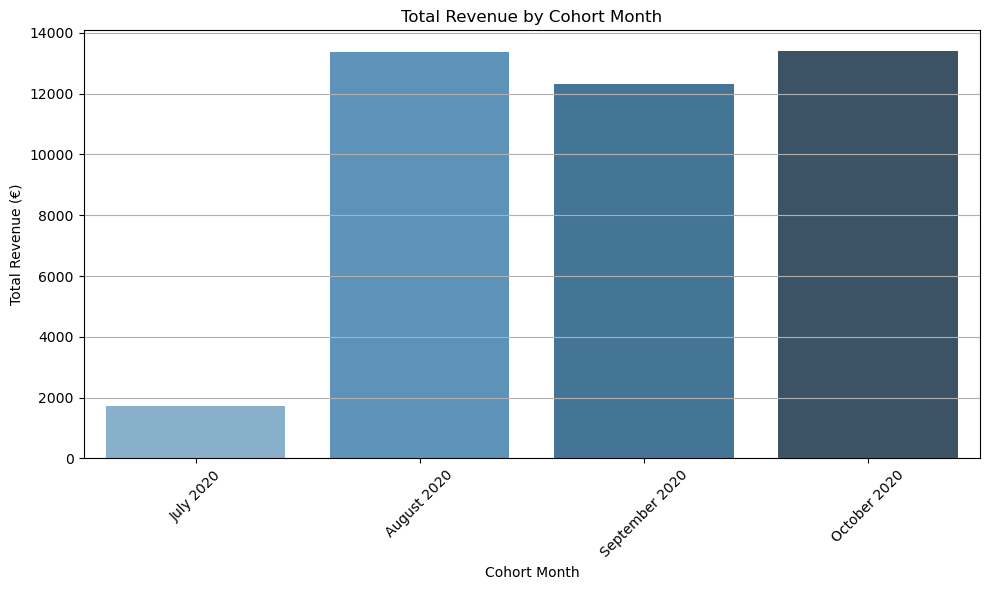

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=total_revenue,
    x='cohort',
    y='total_amount',
    palette='Blues_d'
)

plt.title('Total Revenue by Cohort Month')
plt.xlabel('Cohort Month')
plt.ylabel('Total Revenue (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()